<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import kagglehub
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")

100%|██████████| 58.4k/58.4k [00:00<00:00, 32.3MB/s]

Extracting files...


In [ ]:
import os
import pandas as pd

# List contents of the downloaded path to find the CSV file
file_list = os.listdir(path)
print(f"Files in the downloaded directory: {file_list}")

# Corrected CSV file name based on the actual content of the directory
csv_file_name = 'framingham.csv' # Adjusted to the correct file name
full_csv_path = os.path.join(path, csv_file_name)

# Load the data into a pandas DataFrame
df = pd.read_csv(full_csv_path)

# Display the first 5 rows of the DataFrame
display(df.head())

Files in the downloaded directory: ['framingham.csv']


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


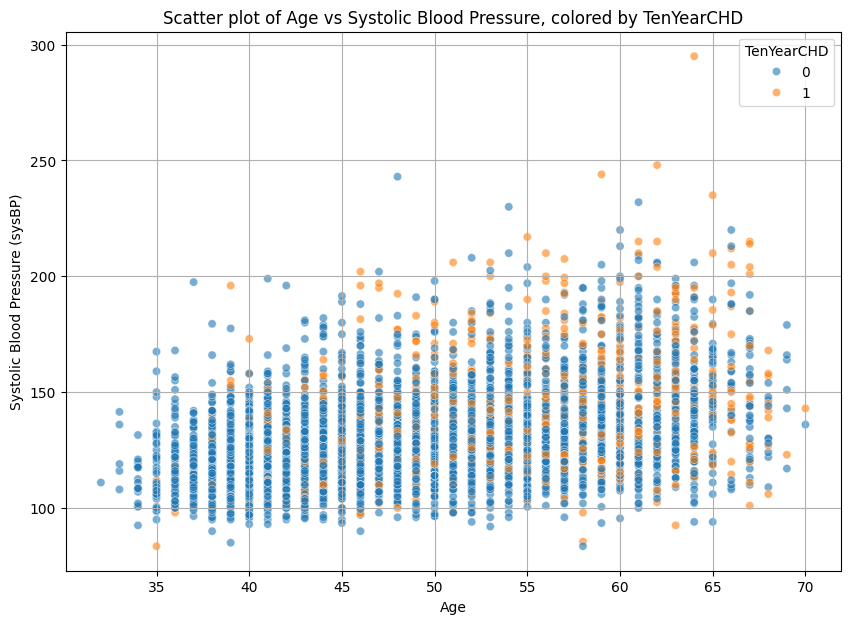

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='age', y='sysBP', hue='TenYearCHD', alpha=0.6)
plt.title('Scatter plot of Age vs Systolic Blood Pressure, colored by TenYearCHD')
plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure (sysBP)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


In [ ]:
from sklearn.model_selection import train_test_split

# Handle missing values by dropping rows with NaNs. This is a common and simple approach
# but more sophisticated imputation methods could be used depending on the analysis requirements.
df_cleaned = df.dropna()

# Define features (X) and target (y)
# 'TenYearCHD' is assumed to be the target variable indicating a 10-year risk of coronary heart disease.
X = df_cleaned.drop('TenYearCHD', axis=1)
y = df_cleaned['TenYearCHD']

# Apply train-test split
# test_size=0.2 means 20% of data will be used for testing, 80% for training
# random_state ensures reproducibility of the split, meaning you get the same split every time you run it
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {x_train.shape}")
print(f"Shape of X_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2924, 15)
Shape of X_test: (732, 15)
Shape of y_train: (2924,)
Shape of y_test: (732,)


In [ ]:
lr=LogisticRegression

In [ ]:
# Re-instantiate LogisticRegression as an object (as it was previously assigned as the class)
lr = LogisticRegression(random_state=42, solver='liblinear') # Added random_state for reproducibility and solver for stability

# Train the Logistic Regression model using the fit method
lr.fit(x_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
pre=lr.predict(x_test)

In [ ]:
accuracy_score(y_test,pre)

0.8333333333333334

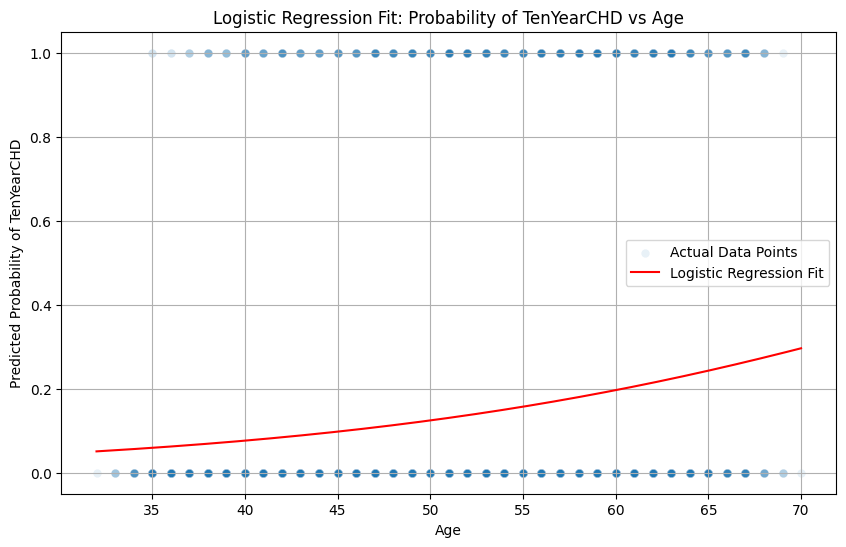

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Create a range of age values for plotting
age_range = np.linspace(X['age'].min(), X['age'].max(), 300)

# Get the mean of all features in X
mean_features = X.mean()

# Create a single-row DataFrame from the mean features
mean_df_row = pd.DataFrame([mean_features.values], columns=X.columns)

# Repeat this single row to create dummy_X with the length of age_range
dummy_X = pd.concat([mean_df_row]*len(age_range), ignore_index=True)

# Now, vary only the 'age' feature in dummy_X
dummy_X['age'] = age_range

# Predict probabilities for the dummy data
# We need the probability of the positive class (TenYearCHD=1)
probabilities = lr.predict_proba(dummy_X)[:, 1]

# Plotting the logistic fit line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['age'], y=y, alpha=0.1, label='Actual Data Points')
plt.plot(age_range, probabilities, color='red', label='Logistic Regression Fit')

plt.title('Logistic Regression Fit: Probability of TenYearCHD vs Age')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of TenYearCHD')
plt.legend()
plt.grid(True)
plt.show()

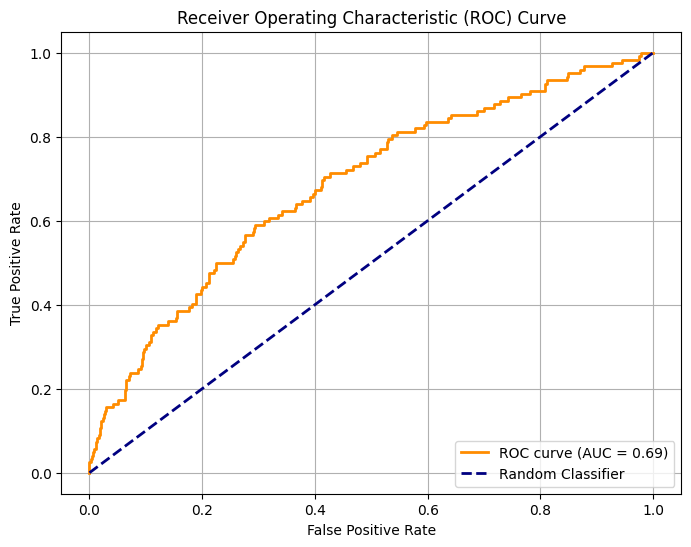

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Get predicted probabilities for the positive class (TenYearCHD=1)
y_pred_proba = lr.predict_proba(x_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate Area Under the Curve (AUC)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve helps evaluate the model's ability to discriminate between classes. A higher AUC (Area Under the Curve) generally indicates a better performing model. Now, let's look at the Confusion Matrix to see the types of correct and incorrect predictions.

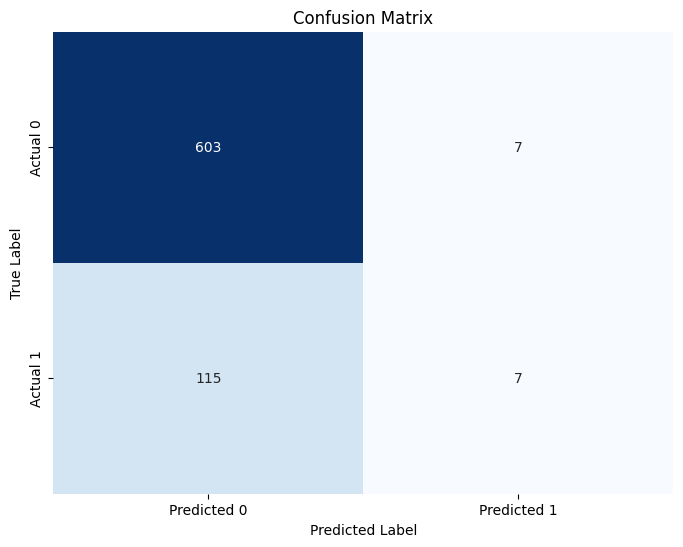

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, pre)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

" Code from Scratch"


In [ ]:
import numpy as np # Ensure numpy is imported for numerical operations
from sklearn.metrics import accuracy_score # Import accuracy_score for tracking

class LogisticRegressionScratch:
    def __init__(self, lr=0.5, n_iterations=4000):
        self.lr = lr
        self.n_iterations = n_iterations
        self.weights = None
        self.history = {'accuracy': [], 'iterations': []} # Added history attribute

    def _sigmoid(self, z):
        # Corrected sigmoid formula from 1/1+np.exp(-z) to 1 / (1 + np.exp(-z))
        # Using np.clip to prevent overflow with large negative numbers
        z = np.clip(z, -500, 500) # Clip values to avoid exp overflow/underflow
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X_b = np.insert(X, 0, 1, axis=1)
        n_samples, n_features = X_b.shape
        self.weights = np.zeros(n_features)

        for i in range(self.n_iterations):
            linear_model = np.dot(X_b, self.weights)
            y_predicted = self._sigmoid(linear_model)
            gradient = (1/n_samples) * np.dot(X_b.T, (y_predicted - y))
            self.weights -= self.lr * gradient

            # Record accuracy every 100 iterations
            if i % 100 == 0:
                y_train_pred = self.predict(X)
                train_accuracy = accuracy_score(y, y_train_pred)
                self.history['accuracy'].append(train_accuracy)
                self.history['iterations'].append(i)

        return self.weights[0], self.weights[1:]

    def predict_proba(self, X):
        X_b = np.insert(X, 0, 1, axis=1)
        linear_model = np.dot(X_b, self.weights)
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [ ]:
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


In [ ]:
import os
import pandas as pd

# List contents of the downloaded path to find the CSV file
file_list = os.listdir(path)
print(f"Files in the downloaded directory: {file_list}")

# Assuming the CSV file is named 'data.csv' based on typical Kaggle datasets or previous interaction.
# If there are multiple CSVs, this might need manual adjustment.
# For 'breast-cancer-wisconsin-data', the main file is often 'data.csv'
cancer_csv_file_name = 'data.csv'
full_cancer_csv_path = os.path.join(path, cancer_csv_file_name)

# Load the data into a new pandas DataFrame called df_cancer
df_cancer = pd.read_csv(full_cancer_csv_path)

# Display the first 5 rows of the DataFrame
display(df_cancer.head())

Files in the downloaded directory: ['data.csv']


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop unnecessary columns from df_cancer
# 'id' is just an identifier, 'Unnamed: 32' is an empty column
X_cancer = df_cancer.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
y_cancer = df_cancer['diagnosis']

# Encode the target variable 'diagnosis' (M=1, B=0)
y_cancer = y_cancer.map({'M': 1, 'B': 0})

# Split the cancer data into training and testing sets
x_cancer_train, x_cancer_test, y_cancer_train, y_cancer_test = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler
scaler = StandardScaler()
x_cancer_train_scaled = scaler.fit_transform(x_cancer_train)
x_cancer_test_scaled = scaler.transform(x_cancer_test)

print(f"Shape of x_cancer_train_scaled: {x_cancer_train_scaled.shape}")
print(f"Shape of x_cancer_test_scaled: {x_cancer_test_scaled.shape}")

# Instantiate and train the custom Logistic Regression model
# Using the same learning rate and iterations as defined in the class for now.
custom_lr_cancer = LogisticRegressionScratch(lr=0.5, n_iterations=4000)

# The fit method in LogisticRegressionScratch currently returns bias and weights.
# We will call it to set internal weights.
custom_lr_cancer.fit(x_cancer_train_scaled, y_cancer_train.values)

# Make predictions on the test set
y_cancer_pred = custom_lr_cancer.predict(x_cancer_test_scaled)

# Calculate accuracy
custom_cancer_accuracy = accuracy_score(y_cancer_test, y_cancer_pred)
print(f"Custom Logistic Regression Accuracy on Breast Cancer data: {custom_cancer_accuracy}")

Shape of x_cancer_train_scaled: (455, 30)
Shape of x_cancer_test_scaled: (114, 30)
Custom Logistic Regression Accuracy on Breast Cancer data: 0.9736842105263158


# checking the accuracy,confusion matrix,percision,recall,f1score



=== MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9737     0.9737  0.9737    0.9736
Decision Tree          0.9474     0.9474  0.9474    0.9474


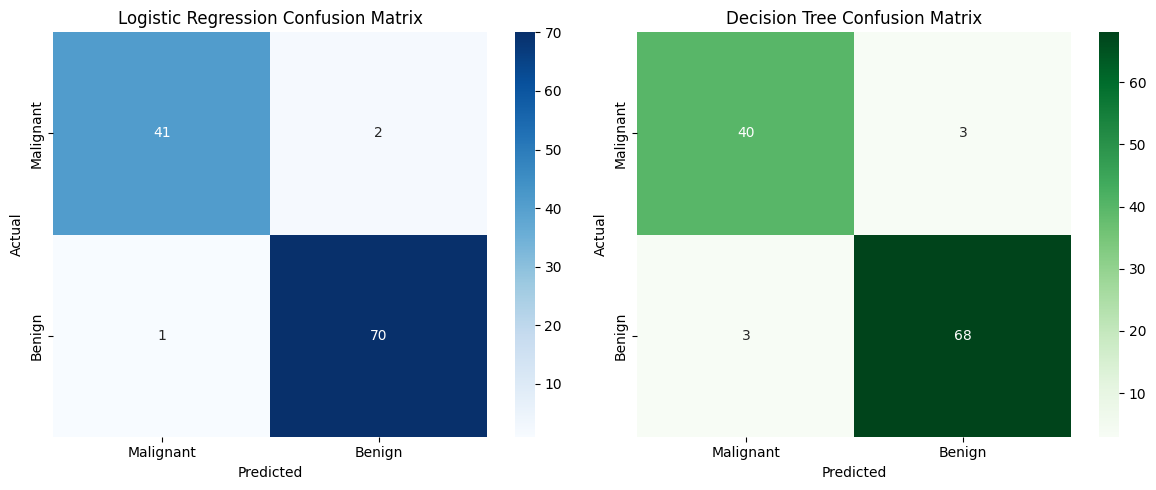

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Load the Breast Cancer Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = Malignant (Cancer), 1 = Benign (Healthy)

# 2. Split into Train and Test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (Crucial for Logistic Regression, optional but harmless for Decision Tree)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize the Models
log_reg = LogisticRegression(random_state=42)
dt_tree = DecisionTreeClassifier(max_depth=4, random_state=42) # Restricted depth to prevent overfitting

# 5. Train the Models
log_reg.fit(X_train_scaled, y_train)
dt_tree.fit(X_train, y_train) # Decision Trees don't require scaled data

# 6. Make Predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_dt = dt_tree.predict(X_test)

# 7. Helper Function to Gather Metrics
def calculate_metrics(y_true, y_pred, average_type='macro'):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=average_type),
        "Recall": recall_score(y_true, y_pred, average=average_type),
        "F1-Score": f1_score(y_true, y_pred, average=average_type)
    }

metrics_log = calculate_metrics(y_test, y_pred_log, average_type='weighted')
metrics_dt = calculate_metrics(y_test, y_pred_dt, average_type='weighted')

# 8. Display Results Side-by-Side
df_compare = pd.DataFrame([metrics_log, metrics_dt], index=["Logistic Regression", "Decision Tree"])
print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(df_compare.round(4))

# 9. Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
axes[1].set_title("Decision Tree Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# discussion of the roc curve here


In [1]:
import kagglehub
path = kagglehub.dataset_download("akshaydattatraykhare/diabetes-dataset")

Using Colab cache for faster access to the 'diabetes-dataset' dataset.


In [2]:
import os
import pandas as pd

# List contents of the downloaded path to find the CSV file
file_list = os.listdir(path)
print(f"Files in the downloaded directory: {file_list}")

# Assuming the CSV file is named 'diabetes.csv' based on typical Kaggle datasets
data_csv_file_name = 'diabetes.csv'
full_data_csv_path = os.path.join(path, data_csv_file_name)

# Load the data into a new pandas DataFrame called df_diabetes
df_diabetes = pd.read_csv(full_data_csv_path)

# Display the first 5 rows of the DataFrame
display(df_diabetes.head())

Files in the downloaded directory: ['diabetes.csv']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Preprocessing the Diabetes Dataset

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inspect the data for '0' values in columns where they are biologically implausible
# These '0's are essentially missing values that need to be handled.
print("Original '0' counts in relevant columns:")
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    print(f"{col}: {(df_diabetes[col] == 0).sum()}")

# Replace '0' values with NaN in the identified columns
# This makes them recognizable as missing data for subsequent handling.
df_diabetes_cleaned = df_diabetes.copy()
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df_diabetes_cleaned[col] = df_diabetes_cleaned[col].replace(0, np.nan)

# Drop rows with NaN values. This is a simple approach; more advanced imputation could be used.
df_diabetes_cleaned = df_diabetes_cleaned.dropna()

print(f"\nShape after cleaning: {df_diabetes_cleaned.shape}")

# Define features (X) and target (y)
# 'Outcome' is the target variable indicating diabetes (1) or no diabetes (0)
X_diabetes = df_diabetes_cleaned.drop('Outcome', axis=1)
y_diabetes = df_diabetes_cleaned['Outcome']

# Split the cleaned data into training and testing sets
# test_size=0.2 means 20% of data for testing, random_state for reproducibility
x_diabetes_train, x_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)

print(f"\nShape of x_diabetes_train: {x_diabetes_train.shape}")
print(f"Shape of x_diabetes_test: {x_diabetes_test.shape}")

Original '0' counts in relevant columns:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11

Shape after cleaning: (392, 9)

Shape of x_diabetes_train: (313, 8)
Shape of x_diabetes_test: (79, 8)


### Building and Training the Logistic Regression Pipeline

In [4]:
# Create a pipeline for preprocessing and model training
# Step 1: StandardScaler to scale the features
# Step 2: LogisticRegression model with a stable solver and random_state for reproducibility
# 'liblinear' solver works well for smaller datasets and handles L1/L2 regularization.
# 'C' parameter (inverse of regularization strength) is set to 0.1 for some regularization.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear', random_state=42, C=0.1))
])

# Train the pipeline on the training data
pipeline.fit(x_diabetes_train, y_diabetes_train)

print("Pipeline trained successfully!")

Pipeline trained successfully!


### Evaluating the Model Performance


False Positive Rate (FPR):
 [0.         0.01923077 0.01923077 0.03846154 0.03846154 0.05769231
 0.05769231 0.07692308 0.07692308 0.09615385 0.09615385 0.11538462
 0.11538462 0.19230769 0.19230769 0.23076923 0.23076923 0.25
 0.25       0.32692308 0.32692308 0.36538462 0.36538462 0.5
 0.5        0.51923077 0.51923077 0.65384615 0.65384615 1.        ]

True Positive Rate (TPR):
 [0.         0.         0.2962963  0.2962963  0.37037037 0.37037037
 0.48148148 0.48148148 0.51851852 0.51851852 0.55555556 0.55555556
 0.59259259 0.59259259 0.62962963 0.62962963 0.66666667 0.66666667
 0.77777778 0.77777778 0.81481481 0.81481481 0.85185185 0.85185185
 0.92592593 0.92592593 0.96296296 0.96296296 1.         1.        ]

Thresholds:
 [       inf 0.98529875 0.77918055 0.72304305 0.6956453  0.68401314
 0.61961985 0.61440498 0.61342742 0.6117215  0.5640021  0.54785882
 0.5388374  0.4948006  0.41237061 0.39103506 0.3617923  0.35115957
 0.33362752 0.31758018 0.30514297 0.2558327  0.25572438 0.18575348
 0

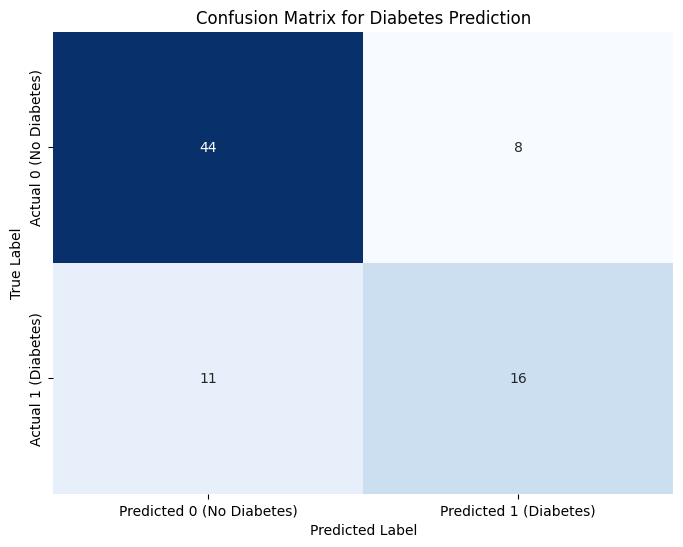

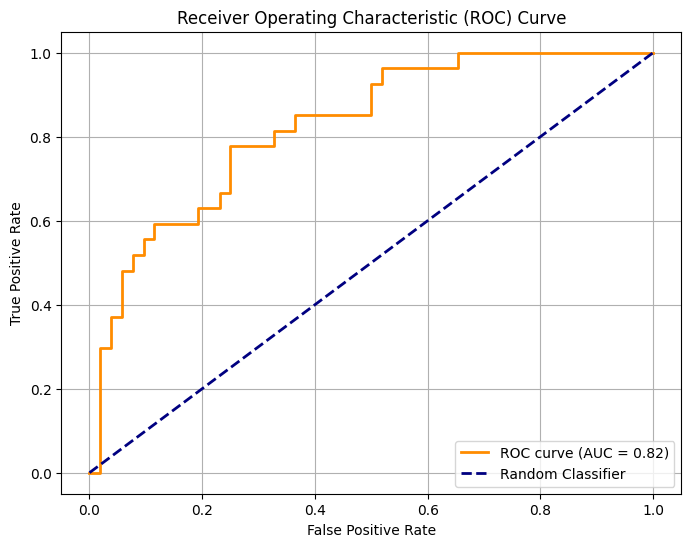

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the trained pipeline
y_diabetes_pred = pipeline.predict(x_diabetes_test)

# Get predicted probabilities for the positive class (Outcome=1)
y_diabetes_proba = pipeline.predict_proba(x_diabetes_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_diabetes_test, y_diabetes_proba)

# Calculate Area Under the Curve (AUC)
roc_auc = roc_auc_score(y_diabetes_test, y_diabetes_proba)

# Print FPR, TPR, and Thresholds
print("\nFalse Positive Rate (FPR):\n", fpr)
print("\nTrue Positive Rate (TPR):\n", tpr)
print("\nThresholds:\n", thresholds)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_diabetes_test, y_diabetes_pred)
print(f"\nAccuracy of the Logistic Regression Pipeline: {accuracy:.4f}")

# Display classification report for more detailed metrics
print("\nClassification Report:")
print(classification_report(y_diabetes_test, y_diabetes_pred))

# Display confusion matrix
cm_diabetes = confusion_matrix(y_diabetes_test, y_diabetes_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_diabetes, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (No Diabetes)', 'Predicted 1 (Diabetes)'],
            yticklabels=['Actual 0 (No Diabetes)', 'Actual 1 (Diabetes)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Diabetes Prediction')
plt.show()

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Determining Optimal Threshold from ROC Curve

The optimal threshold based on Youden's J statistic is: 0.3336
TPR at optimal threshold: 0.7778
FPR at optimal threshold: 0.2500


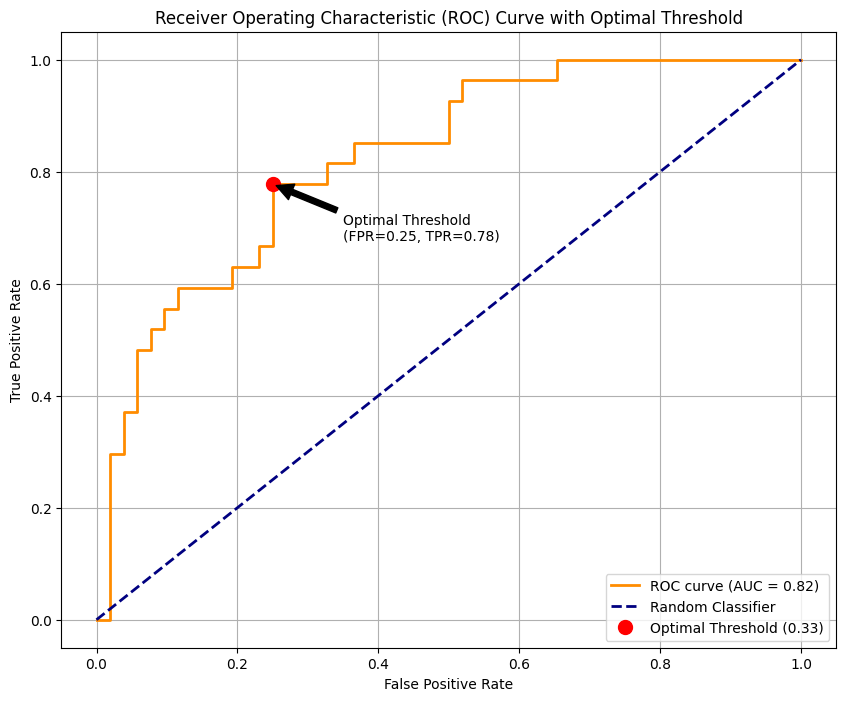

In [7]:
# Calculate Youden's J statistic (J = TPR - FPR) for each threshold
J = tpr - fpr

# Find the optimal threshold (the one that maximizes J)
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"The optimal threshold based on Youden's J statistic is: {optimal_threshold:.4f}")

# Optionally, you can also print the TPR and FPR at this optimal threshold
print(f"TPR at optimal threshold: {tpr[optimal_idx]:.4f}")
print(f"FPR at optimal threshold: {fpr[optimal_idx]:.4f}")

# Plot the ROC curve again, highlighting the optimal threshold
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Mark the optimal threshold point
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'o', markersize=10, color='red',
         label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.annotate(f'Optimal Threshold\n(FPR={fpr[optimal_idx]:.2f}, TPR={tpr[optimal_idx]:.2f})',
             xy=(fpr[optimal_idx], tpr[optimal_idx]), xytext=(fpr[optimal_idx] + 0.1, tpr[optimal_idx] - 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve with Optimal Threshold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Applying Support Vector Machine (SVM) Classifier

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-using the preprocessed and split data from the Logistic Regression steps
# X_diabetes, y_diabetes, x_diabetes_train, x_diabetes_test, y_diabetes_train, y_diabetes_test are already available.

# Create a pipeline for preprocessing and SVM training
# Step 1: StandardScaler to scale the features
# Step 2: SVC (Support Vector Classifier) with a 'rbf' kernel (a common choice for non-linear decision boundaries).
# probability=True is essential for `predict_proba` to calculate ROC curve.
# random_state for reproducibility.
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

# Train the SVM pipeline on the training data
svm_pipeline.fit(x_diabetes_train, y_diabetes_train)

print("SVM Pipeline trained successfully!")

SVM Pipeline trained successfully!


### Evaluating SVM Model Performance

Accuracy of the SVM Pipeline: 0.7468

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.78      0.87      0.82        52
           1       0.67      0.52      0.58        27

    accuracy                           0.75        79
   macro avg       0.72      0.69      0.70        79
weighted avg       0.74      0.75      0.74        79



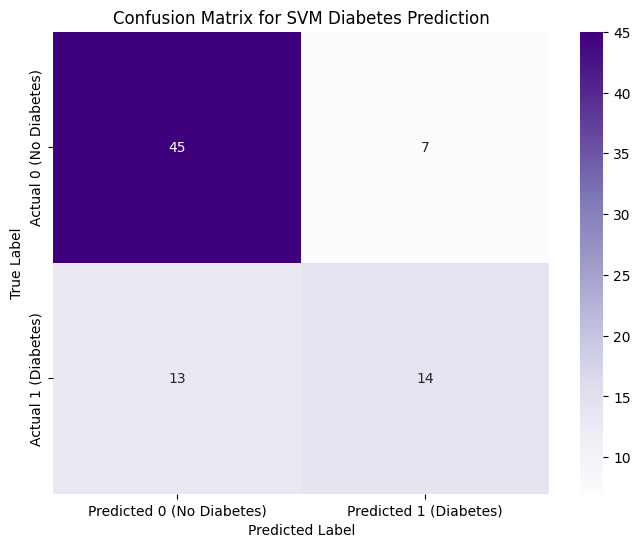

In [9]:
# Make predictions on the test set using the trained SVM pipeline
y_svm_pred = svm_pipeline.predict(x_diabetes_test)

# Get predicted probabilities for the positive class (Outcome=1) for ROC curve
y_svm_proba = svm_pipeline.predict_proba(x_diabetes_test)[:, 1]

# Evaluate the SVM model's accuracy
svm_accuracy = accuracy_score(y_diabetes_test, y_svm_pred)
print(f"Accuracy of the SVM Pipeline: {svm_accuracy:.4f}")

# Display classification report for more detailed metrics
print("\nClassification Report (SVM):")
print(classification_report(y_diabetes_test, y_svm_pred))

# Display confusion matrix for SVM
cm_svm = confusion_matrix(y_diabetes_test, y_svm_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0 (No Diabetes)', 'Predicted 1 (Diabetes)'],
            yticklabels=['Actual 0 (No Diabetes)', 'Actual 1 (Diabetes)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Diabetes Prediction')
plt.show()

### ROC Curve and Optimal Threshold for SVM

### Comparing ROC Curves: Logistic Regression vs. SVM

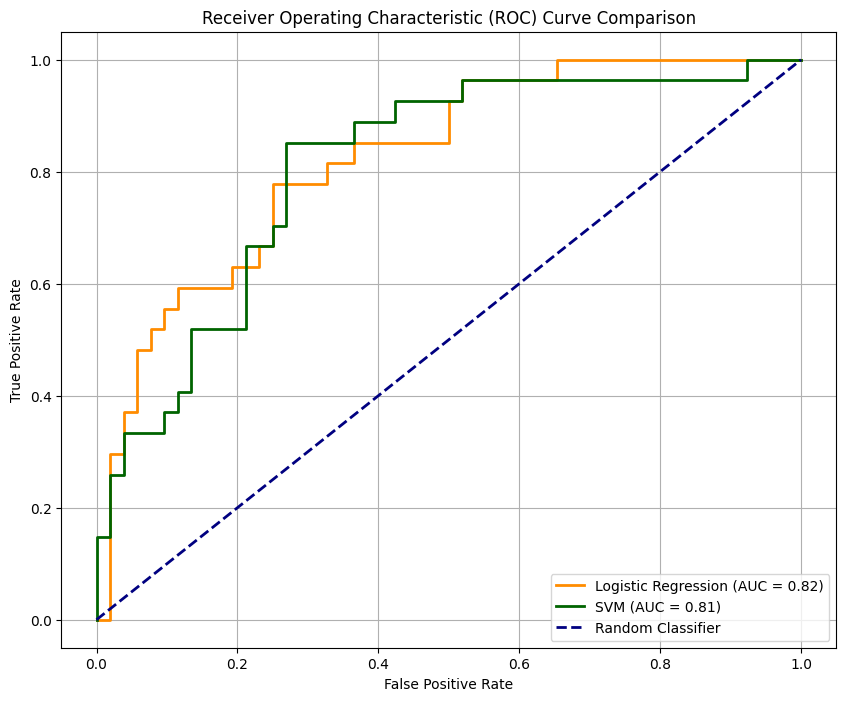

In [11]:
plt.figure(figsize=(10, 8))

# Plot ROC curve for Logistic Regression
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')

# Plot ROC curve for SVM
plt.plot(fpr_svm, tpr_svm, color='darkgreen', lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


False Positive Rate (FPR) for SVM:
 [0.         0.         0.         0.01923077 0.01923077 0.03846154
 0.03846154 0.09615385 0.09615385 0.11538462 0.11538462 0.13461538
 0.13461538 0.21153846 0.21153846 0.25       0.25       0.26923077
 0.26923077 0.36538462 0.36538462 0.42307692 0.42307692 0.51923077
 0.51923077 0.92307692 0.92307692 1.        ]

True Positive Rate (TPR) for SVM:
 [0.         0.03703704 0.14814815 0.14814815 0.25925926 0.25925926
 0.33333333 0.33333333 0.37037037 0.37037037 0.40740741 0.40740741
 0.51851852 0.51851852 0.66666667 0.66666667 0.7037037  0.7037037
 0.85185185 0.85185185 0.88888889 0.88888889 0.92592593 0.92592593
 0.96296296 0.96296296 1.         1.        ]

Thresholds for SVM:
 [       inf 0.9225158  0.85174849 0.83966631 0.80149203 0.7433995
 0.67821631 0.64584326 0.62226602 0.60473717 0.59700967 0.59645431
 0.52001764 0.38675651 0.33519725 0.2930685  0.28806309 0.27827735
 0.2566973  0.20879107 0.19318461 0.15929821 0.15851517 0.1333768
 0.11915125 

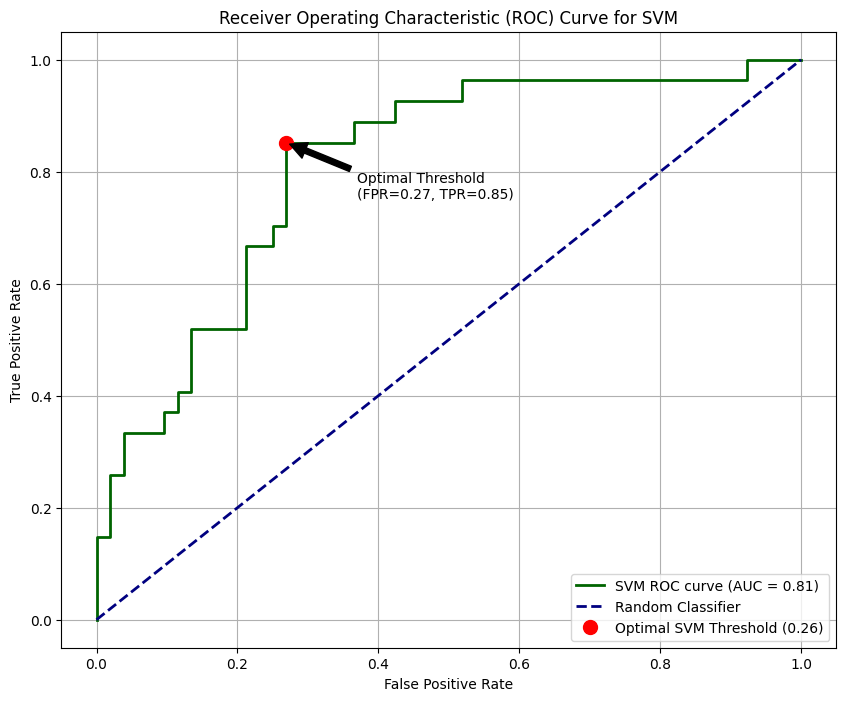

In [10]:
# Calculate ROC curve values for SVM
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_diabetes_test, y_svm_proba)

# Calculate Area Under the Curve (AUC) for SVM
roc_auc_svm = roc_auc_score(y_diabetes_test, y_svm_proba)

# Print FPR, TPR, and Thresholds for SVM
print("\nFalse Positive Rate (FPR) for SVM:\n", fpr_svm)
print("\nTrue Positive Rate (TPR) for SVM:\n", tpr_svm)
print("\nThresholds for SVM:\n", thresholds_svm)
print(f"\nROC AUC Score for SVM: {roc_auc_svm:.4f}")

# Calculate Youden's J statistic (J = TPR - FPR) for each SVM threshold
J_svm = tpr_svm - fpr_svm

# Find the optimal threshold for SVM (the one that maximizes J)
optimal_idx_svm = np.argmax(J_svm)
optimal_threshold_svm = thresholds_svm[optimal_idx_svm]

print(f"\nThe optimal threshold for SVM based on Youden's J statistic is: {optimal_threshold_svm:.4f}")
print(f"TPR at optimal SVM threshold: {tpr_svm[optimal_idx_svm]:.4f}")
print(f"FPR at optimal SVM threshold: {fpr_svm[optimal_idx_svm]:.4f}")

# Plot the ROC curve for SVM
plt.figure(figsize=(10, 8))
plt.plot(fpr_svm, tpr_svm, color='darkgreen', lw=2, label=f'SVM ROC curve (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Mark the optimal threshold point for SVM
plt.plot(fpr_svm[optimal_idx_svm], tpr_svm[optimal_idx_svm], 'o', markersize=10, color='red',
         label=f'Optimal SVM Threshold ({optimal_threshold_svm:.2f})')
plt.annotate(f'Optimal Threshold\n(FPR={fpr_svm[optimal_idx_svm]:.2f}, TPR={tpr_svm[optimal_idx_svm]:.2f})',
             xy=(fpr_svm[optimal_idx_svm], tpr_svm[optimal_idx_svm]),
             xytext=(fpr_svm[optimal_idx_svm] + 0.1, tpr_svm[optimal_idx_svm] - 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()